In [4]:
from src.FractionsCorrelation import (
    measure_correlations_by_L_and_gap,
    summarize_gap_independence,
    read_fraction_values_by_L_and_gap,
)
import json
import matplotlib.pyplot as plt
import lzma

In [5]:
corr = measure_correlations_by_L_and_gap(
    "../SOP_data",
    measure="p_stab_bond",
    L_values=16384,
    gaps=[0.5, 1.0, 1.5, 2.0],
    lags=range(1, 11),
)

summary = summarize_gap_independence(corr)

summary[[
    "L", "gap",
    "max_abs_correlation",
    "mean_abs_correlation",
    "min_p_value",
    "gap_rank",
    "is_best_gap",
]]

,L,gap,max_abs_correlation,mean_abs_correlation,min_p_value,gap_rank,is_best_gap
0,16384,0.5,0.133000,0.048585,0.206877,1,True
1,16384,2.0,0.157815,0.070091,0.118925,2,False
2,16384,1.5,0.204483,0.082109,0.057314,3,False
3,16384,1.0,0.264305,0.089742,0.006003,4,False


p_mean = 0.5228817402232777 ± 0.0015162868883380454, σ = 0.035560079587371986
p_mean = 0.4562134504318237 ± 0.0017727862372234672, σ = 0.03718627783028483
p_mean = 0.3997265692913171 ± 0.0021774388911815147, σ = 0.03955514177946817
p_mean = 0.3249500719591593 ± 0.003560148268289845, σ = 0.044466237618943215
p_mean = 0.2782625437044261 ± 0.004101823048803712, σ = 0.043795485668062885


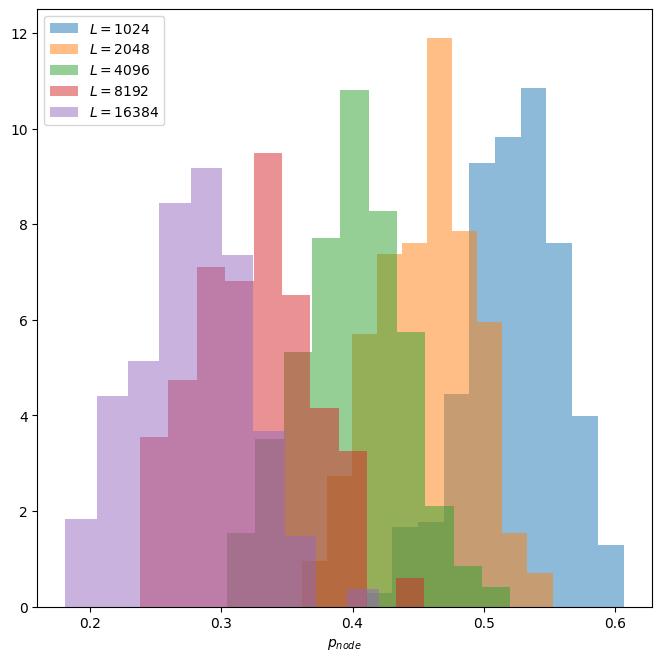

In [17]:
import numpy as np
L_lst = [1024, 2048, 4096, 8192,16384]

base = 6.5
n_rows = 1
n_columns = 1

fs_title = 20
fs_label = 18
fig, axes = plt.subplots(n_rows, n_columns, figsize=(n_columns*base, n_rows*base), constrained_layout=True)

gap = 1.0
prop = "p_inst_node"
p_mean_node = []
for L in L_lst:
    values = read_fraction_values_by_L_and_gap(
    "../SOP_data",
    measures=prop,
    L_values=L,
    gaps=[gap],
    )
    p_stab = values[(L, gap)][0]["data"][prop]
    p_avarage = np.mean(p_stab)
    std = np.std(p_stab, ddof=1)
    sem = std / np.sqrt(np.size(p_stab))

    p_mean_node.append(p_avarage)
    print(f"p_mean = {p_avarage} ± {sem}, σ = {std}")
    axes.hist(p_stab,alpha=0.5, density=True ,label=f"$L={L}$")
    axes.set_xlabel(r'$p_{node}$')
plt.legend()
plt.show()

A = 2.638881
d = 1.769043
R² = 0.999885
RMSE(log) = 1.863707e-02


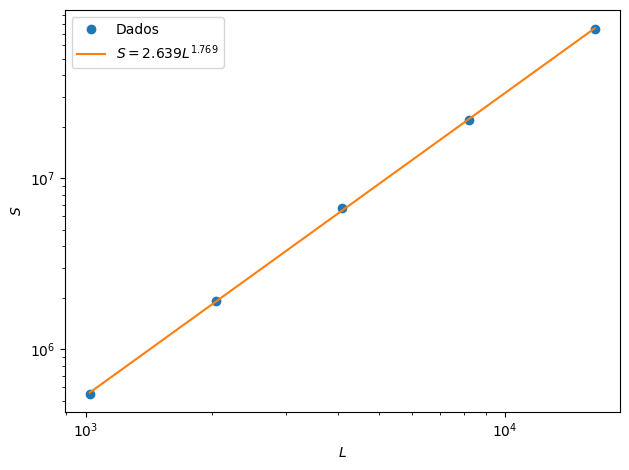

In [18]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Dados
x = np.array(L_lst, dtype=float)
y = np.array(p_mean_node, dtype=float)*x**2

# Transformação log-log
x_log = np.log(x).reshape(-1, 1)
y_log = np.log(y)

# Ajuste linear
model = LinearRegression()
model.fit(x_log, y_log)

# Predição no espaço log
y_pred_log = model.predict(x_log)

# Parâmetros
d = model.coef_[0]
log_A = model.intercept_
A = np.exp(log_A)

# Métricas no espaço log
r2 = r2_score(y_log, y_pred_log)
rmse = np.sqrt(mean_squared_error(y_log, y_pred_log))

print(f"A = {A:.6f}")
print(f"d = {d:.6f}")
print(f"R² = {r2:.6f}")
print(f"RMSE(log) = {rmse:.6e}")

# Curva ajustada no espaço original
L_fit = np.logspace(
    np.log10(x.min()),
    np.log10(x.max()),
    200
)

S_fit = A * L_fit**d

# Plot
plt.plot(x, y, 'o', label='Dados')
plt.plot(
    L_fit,
    S_fit,
    '-',
    label=fr'$S = {A:.3f}L^{{{d:.3f}}}$'
)

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$L$')
plt.ylabel(r'$S$')

plt.legend()
plt.tight_layout()

plt.show()

p_mean = 0.3106804858551317 ± 0.0004961070723943516, σ = 0.011634742154591649
p_mean = 0.27888872981402274 ± 0.0005990528767516397, σ = 0.01256583915317806
p_mean = 0.24812706089251577 ± 0.0008500258719462708, σ = 0.015441486793140936
p_mean = 0.2106408326324622 ± 0.0016226059070084892, σ = 0.020266341282914865
p_mean = 0.18411022097349575 ± 0.0019199817225579111, σ = 0.020499795094220688


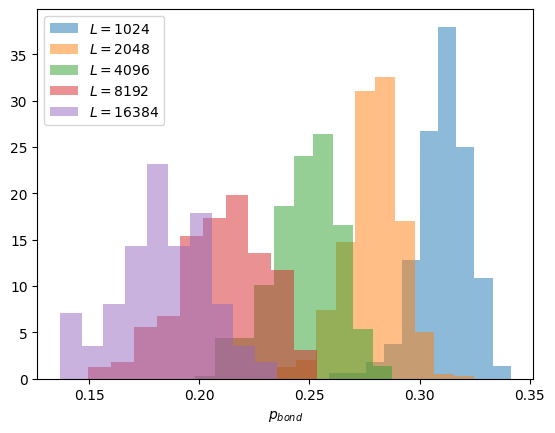

In [22]:
import numpy as np
L_lst = [1024, 2048, 4096, 8192,16384]
#gaps = [0.5, 1.0, 1.5, 2.0]
gap = 1.0
prop = "p_stab_bond"
p_mean_bond = []

for L in L_lst:
    values = read_fraction_values_by_L_and_gap(
    "../SOP_data",
    measures=prop,
    L_values=L,
    gaps=[gap],
    )
    p_stab = values[(L, gap)][0]["data"][prop]
    p_avarage = np.mean(p_stab)
    std = np.std(p_stab, ddof=1)
    sem = std / np.sqrt(np.size(p_stab))
    p_mean_bond.append(p_avarage)
    
    print(f"p_mean = {p_avarage} ± {sem}, σ = {std}")
    plt.hist(p_stab, alpha=0.5, density=True ,label=f"$L={L}$")
    plt.xlabel(r'$p_{bond}$')
plt.legend()
plt.show()

In [18]:
#p_mean_node
R = [i/j for i,j in zip(p_mean_node, p_mean_bond)]
R

[2.000002867316053,
 2.0000014606686984,
 1.9999975538608608,
 2.000000744662703,
 1.9999997923967865]

# Fractal Dimension

378009.7509090909
1468336.2795454545
5548546.493939394
21466819.42948718
77409595.83333333


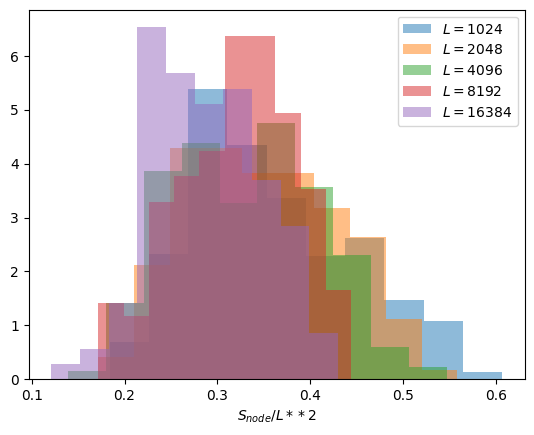

In [21]:
import numpy as np
L_lst = [1024, 2048, 4096, 8192,16384]
#gaps = [0.5, 1.0, 1.5, 2.0]
gap = 1.0
prop = "S_stab"
S_mean_node = []
for L in L_lst:
    values = read_fraction_values_by_L_and_gap(
    "../SOP_data",
    measures=prop,
    L_values=L,
    gaps=[gap],
    )
    S_stab = values[(L, gap)][0]["data"][prop]
    norm = [i/L**2 for i in S_stab]
    S_avarage = np.mean(S_stab)
    S_mean_node.append(S_avarage)
    print(S_avarage)
    plt.hist(norm,alpha=0.5, density=True ,label=f"$L={L}$")
    plt.xlabel(r'$S_{node}/L**2$')
plt.legend()
plt.show()

A = 0.626301
d = 1.922574
R² = 0.999910
RMSE(log) = 1.790427e-02


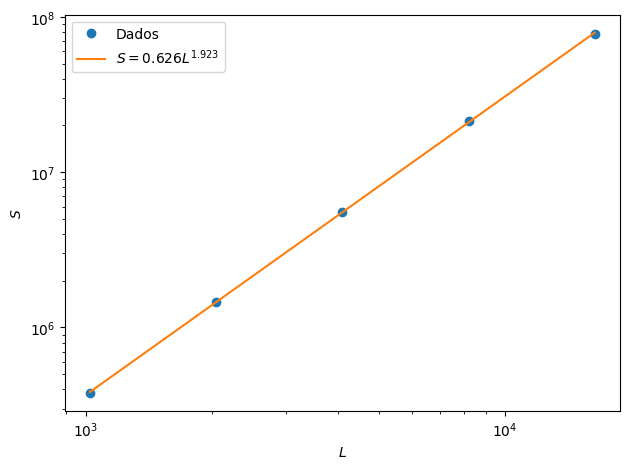

In [22]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Dados
x = np.array(L_lst, dtype=float)
y = np.array(S_mean_node, dtype=float)

# Transformação log-log
x_log = np.log(x).reshape(-1, 1)
y_log = np.log(y)

# Ajuste linear
model = LinearRegression()
model.fit(x_log, y_log)

# Predição no espaço log
y_pred_log = model.predict(x_log)

# Parâmetros
d = model.coef_[0]
log_A = model.intercept_
A = np.exp(log_A)

# Métricas no espaço log
r2 = r2_score(y_log, y_pred_log)
rmse = np.sqrt(mean_squared_error(y_log, y_pred_log))

print(f"A = {A:.6f}")
print(f"d = {d:.6f}")
print(f"R² = {r2:.6f}")
print(f"RMSE(log) = {rmse:.6e}")

# Curva ajustada no espaço original
L_fit = np.logspace(
    np.log10(x.min()),
    np.log10(x.max()),
    200
)

S_fit = A * L_fit**d

# Plot
plt.plot(x, y, 'o', label='Dados')
plt.plot(
    L_fit,
    S_fit,
    '-',
    label=fr'$S = {A:.3f}L^{{{d:.3f}}}$'
)

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$L$')
plt.ylabel(r'$S$')

plt.legend()
plt.tight_layout()
plt.show()

# Shortest Path

2382.847272727273
5355.234090909091
12264.760606060607
28829.416666666668
68510.0


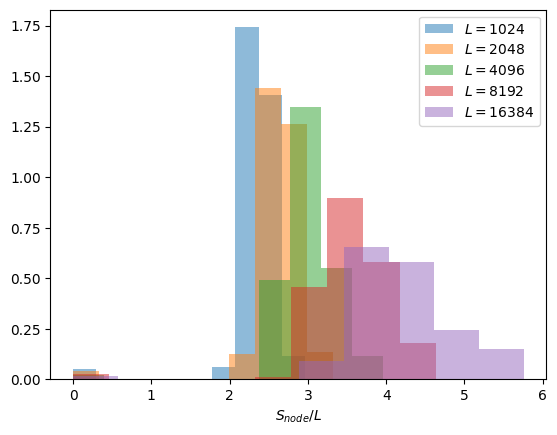

In [13]:
import numpy as np
L_lst = [1024, 2048, 4096, 8192,16384]
#gaps = [0.5, 1.0, 1.5, 2.0]
gap = 1.0
prop = "SP_stab"
SP_mean_node = []
for L in L_lst:
    values = read_fraction_values_by_L_and_gap(
    "../SOP_data",
    measures=prop,
    L_values=L,
    gaps=[gap],
    )
    SP_stab = values[(L, gap)][0]["data"][prop]
    norm = [i/L for i in SP_stab]
    SP_avarage = np.mean(SP_stab)
    SP_mean_node.append(SP_avarage)
    print(SP_avarage)
    plt.hist(norm,alpha=0.5, density=True ,label=f"$L={L}$")
    plt.xlabel(r'$S_{node}/L$')
plt.legend()
plt.show()

A = 0.524780
d = 1.211963
R² = 0.999806
RMSE(log) = 1.653004e-02


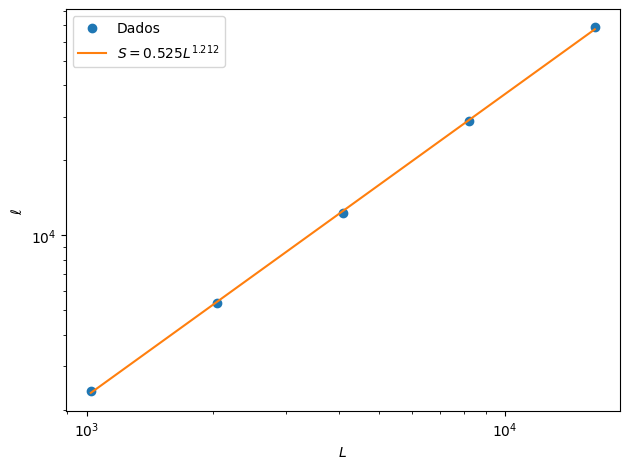

In [14]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Dados
x = np.array(L_lst, dtype=float)
y = np.array(SP_mean_node, dtype=float)

# Transformação log-log
x_log = np.log(x).reshape(-1, 1)
y_log = np.log(y)

# Ajuste linear
model = LinearRegression()
model.fit(x_log, y_log)

# Predição no espaço log
y_pred_log = model.predict(x_log)

# Parâmetros
d = model.coef_[0]
log_A = model.intercept_
A = np.exp(log_A)

# Métricas no espaço log
r2 = r2_score(y_log, y_pred_log)
rmse = np.sqrt(mean_squared_error(y_log, y_pred_log))

print(f"A = {A:.6f}")
print(f"d = {d:.6f}")
print(f"R² = {r2:.6f}")
print(f"RMSE(log) = {rmse:.6e}")

# Curva ajustada no espaço original
L_fit = np.logspace(
    np.log10(x.min()),
    np.log10(x.max()),
    200
)

S_fit = A * L_fit**d

# Plot
plt.plot(x, y, 'o', label='Dados')
plt.plot(
    L_fit,
    S_fit,
    '-',
    label=fr'$S = {A:.3f}L^{{{d:.3f}}}$'
)

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$L$')
plt.ylabel(r'$\ell$')

plt.legend()
plt.tight_layout()
plt.show()